In [1]:
import gymnasium as gym
import numpy as np
import torch
from stable_baselines3 import PPO, DDPG, TD3, SAC
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.evaluation import evaluate_policy


In [21]:
# Cell 1: Imports and General Setup
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt

from stable_baselines3 import PPO, DDPG, TD3, SAC
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.evaluation import evaluate_policy

# Device detection (Mac MPS or CPU)
device = "cpu"
if torch.backends.mps.is_available():
    device = "mps"
print(f"Using device: {device}")

# Wrapper to cast observations to float32 for MPS compatibility
class CastObservation(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        obs_space = env.observation_space
        self.observation_space = gym.spaces.Box(
            low=obs_space.low.astype(np.float32),
            high=obs_space.high.astype(np.float32),
            dtype=np.float32
        )
    def observation(self, obs):
        return obs.astype(np.float32)

Using device: mps


In [22]:
# Cell 2: Environment Creation

def make_env():
    return gym.make("Walker2d-v4")

# Raw eval env for evaluation
raw_eval = gym.make("Walker2d-v4")
eval_env = CastObservation(raw_eval)

# Vec env for training
base_env = DummyVecEnv([make_env])
env = VecNormalize(base_env, norm_obs=True, norm_reward=False, clip_obs=10.0)

# Experiment settings
TIMESTEPS = 500_000
SEED = 0
LR = 3e-4
GAMMA = 0.99
EVAL_FREQ = 100_000
N_EVAL_EPISODES = 5

n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

# Utility: sequential training and evaluation function
def train_and_evaluate_chunk(model, name, model_env, eval_env, timesteps, chunk_size):
    steps = 0
    results = []  # list of (step, mean, std)
    while steps < timesteps:
        s = min(chunk_size, timesteps - steps)
        print(f"\n[{name}] training next {s} steps (total {steps})...")
        model.learn(total_timesteps=s, reset_num_timesteps=False)
        steps += s
        mean, std = evaluate_policy(model, eval_env, n_eval_episodes=N_EVAL_EPISODES, deterministic=True, render=False)
        print(f"[{name}] @ {steps} steps -> mean_reward {mean:.2f} ± {std:.2f}")
        results.append((steps, mean, std))
    return results


Using mps device

[PPO] training next 100000 steps (total 0)...
-----------------------------
| time/              |      |
|    fps             | 366  |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 364          |
|    iterations           | 2            |
|    time_elapsed         | 11           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0040801303 |
|    clip_fraction        | 0.187        |
|    clip_range           | 0.1          |
|    entropy_loss         | -8.51        |
|    explained_variance   | -0.0182      |
|    learning_rate        | 0.0001       |
|    loss                 | 3.53         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0129      |
|    std                  | 1         

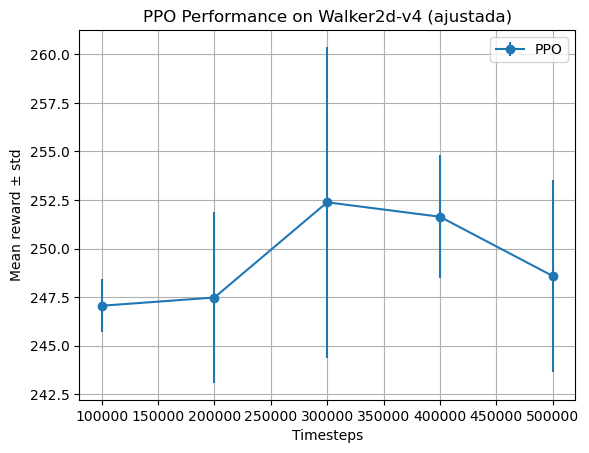

In [23]:
# Cell 3: PPO Training and Plotting (ajustada)
ppo_model = PPO(
    "MlpPolicy", env,
    verbose=1,
    device=device,
    learning_rate=1e-4,       # LR reducido para pasos más finos
    gamma=0.99,
    n_steps=2048,
    batch_size=256,
    gae_lambda=0.98,          # λ más alto para menor varianza
    clip_range=0.1,           # clip_range más conservador
    ent_coef=0.01,            # coeficiente de entropía fijo
    policy_kwargs=dict(net_arch=[512, 512]),  # red más profunda
    seed=SEED
)

# Entrenamiento y evaluación en bloques
ppo_history = train_and_evaluate_chunk(
    ppo_model, "PPO", env, eval_env,
    timesteps=TIMESTEPS,
    chunk_size=EVAL_FREQ
)

# Plot de resultados
steps, means, stds = zip(*ppo_history)
plt.errorbar(steps, means, yerr=stds, label="PPO", marker='o')
plt.title("PPO Performance on Walker2d-v4 (ajustada)")
plt.xlabel("Timesteps")
plt.ylabel("Mean reward ± std")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
from gymnasium.wrappers import RecordVideo
# Wrap the recording environment with CastObservation to ensure float32 obs
gym_env = CastObservation(gym.make("Walker2d-v4", render_mode="rgb_array"))
video_env = RecordVideo(
    gym_env,
    video_folder="videos",
    name_prefix="ppo"
)
obs, _ = video_env.reset(seed=SEED)
obs = obs.astype(np.float32)
for _ in range(1000):
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, _ = video_env.step(action)
    obs = obs.astype(np.float32)
    if terminated or truncated:
        break
video_env.close()

In [7]:
!pip install 'gymnasium[mujoco]'

In [2]:
# Device detection for Mac MPS or CPU
device = "cpu"
if torch.backends.mps.is_available():
    device = "mps"
print(f"Using device: {device}")

Using device: mps


In [11]:
def inspect_env(e):
    # Si es un VecEnv de SB3 (viejo gym API), reset() solo devuelve obs
    reset_out = e.reset()
    if isinstance(reset_out, tuple):
        obs, info = reset_out
    else:
        obs = reset_out
        info = {}
    print("Observation space:", e.observation_space)
    print("Action space:", e.action_space)
    print("Sample obs shape:", np.array(obs).shape)
    # Para VecEnv.step(): devuelve (obs, rewards, dones, infos)
    step_out = e.step(e.action_space.sample())
    if len(step_out) == 5:
        # Gymnasium VecEnv might return (obs, reward, terminated, truncated, info)
        next_obs, reward, terminated, truncated, info = step_out
        done = terminated or truncated
    else:
        # SB3 VecEnv: (obs, rewards, dones, infos)
        next_obs, reward, dones, infos = step_out
        done = dones
    print(f"After one random step -> reward: {reward}, done: {done}")

Using mps device

[PPO] training next 100000 steps (total 0)...


/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(
/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 383  |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 266         |
|    iterations           | 2           |
|    time_elapsed         | 15          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.019335393 |
|    clip_fraction        | 0.167       |
|    clip_range           | 0.2         |
|    entropy_loss         | -8.48       |
|    explained_variance   | -0.565      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.155       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0283     |
|    std                  | 0.992       |
|    value_loss           | 0.463       |
----------------------------------

/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


[PPO] @ 100000 steps -> mean_reward 248.80 ± 9.13

[PPO] training next 100000 steps (total 100000)...
-------------------------------
| time/              |        |
|    fps             | 337    |
|    iterations      | 1      |
|    time_elapsed    | 6      |
|    total_timesteps | 102400 |
-------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 290         |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 104448      |
| train/                  |             |
|    approx_kl            | 0.014265908 |
|    clip_fraction        | 0.19        |
|    clip_range           | 0.2         |
|    entropy_loss         | -7.15       |
|    explained_variance   | 0.966       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0295     |
|    n_updates            | 500         |
|    policy_gradient_loss | -0.0266     |
| 

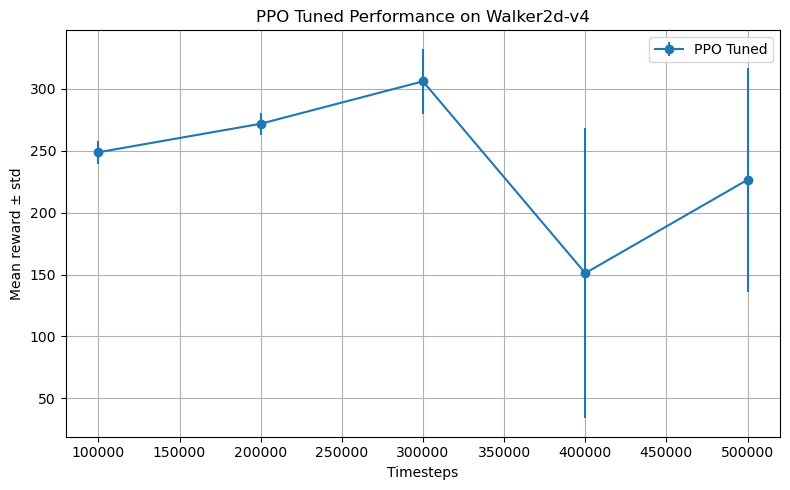

In [26]:
# Cell 3: PPO Training and Plotting (tuned hyperparameters)

# Ensure reward normalization is active
from stable_baselines3.common.utils import get_schedule_fn
env = VecNormalize(base_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

ppo_model = PPO(
    "MlpPolicy", env,
    verbose=1,
    device=device,
    learning_rate=get_schedule_fn(3e-4),  # decays linearly from 3e-4 to 0
    gamma=0.99,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,
    policy_kwargs=dict(net_arch=[dict(pi=[64,64], vf=[64,64])]),
    seed=SEED
)

# Train and evaluate
ppo_history = train_and_evaluate_chunk(
    ppo_model, "PPO", env, eval_env,
    timesteps=TIMESTEPS,
    chunk_size=EVAL_FREQ
)

# Plot results
timesteps_list, mean_rewards, std_rewards = zip(*ppo_history)
plt.figure(figsize=(8,5))
plt.errorbar(timesteps_list, mean_rewards, yerr=std_rewards, label="PPO Tuned", marker='o')
plt.title("PPO Tuned Performance on Walker2d-v4")
plt.xlabel("Timesteps")
plt.ylabel("Mean reward ± std")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# 2. Vectorized and normalized env for training

def make_env():
    return gym.make("Walker2d-v4")

base_env = DummyVecEnv([make_env])
env = VecNormalize(base_env, norm_obs=True, norm_reward=False, clip_obs=10.0)

# 3. Experiment settings
TIMESTEPS = 500_000       # Total timesteps per agent (~1.5-2h)
SEED = 0
LR = 3e-4
GAMMA = 0.99
EVAL_FREQ = 100_000      # Evaluate every this many timesteps
N_EVAL_EPISODES = 5

# 4. Evaluation environment (raw, unnormalized) with casting to float32
raw_env = gym.make("Walker2d-v4")

# Custom wrapper to cast observations to float32 for MPS compatibility
import numpy as np
import gymnasium as gym

class CastObservation(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        obs_space = env.observation_space
        # redefinimos el espacio de observaciones a float32
        self.observation_space = gym.spaces.Box(
            low=obs_space.low.astype(np.float32),
            high=obs_space.high.astype(np.float32),
            dtype=np.float32
        )
    def observation(self, obs):
        return obs.astype(np.float32)

# Creamos el entorno de evaluación y aplicamos el wrapper de casting
gym_env = gym.make("Walker2d-v4")
eval_env = CastObservation(gym_env)

def train_and_evaluate(name, model, eval_env):
    timesteps = []
    mean_rewards = []
    std_rewards = []
    total_steps = 0

    # Continue training in chunks until reaching TIMESTEPS
    while total_steps < TIMESTEPS:
        train_steps = min(EVAL_FREQ, TIMESTEPS - total_steps)
        print(f"\n--- {name}: training for {train_steps} steps (total so far: {total_steps}) ---")
        model.learn(total_timesteps=train_steps, reset_num_timesteps=False)
        total_steps += train_steps

        mean, std = evaluate_policy(
            model, eval_env,
            n_eval_episodes=N_EVAL_EPISODES,
            deterministic=True,
            render=False
        )
        timesteps.append(total_steps)
        mean_rewards.append(mean)
        std_rewards.append(std)
        print(f"{name} @ {total_steps}: mean_reward={mean:.2f} ± {std:.2f}")

    return timesteps, mean_rewards, std_rewards

# 5. Define models sequentially
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

models = {
    'PPO': PPO(
        "MlpPolicy", env,
        verbose=1,
        device=device,
        learning_rate=LR,
        gamma=GAMMA,
        n_steps=2048,
        batch_size=256,
        policy_kwargs=dict(net_arch=[dict(pi=[256,256], vf=[256,256])]),
        seed=SEED
    ),
    'DDPG': DDPG(
        "MlpPolicy", env,
        verbose=1,
        device=device,
        learning_rate=LR,
        gamma=GAMMA,
        batch_size=256,
        buffer_size=100_000,
        tau=0.005,
        action_noise=action_noise,
        seed=SEED
    ),
    'TD3': TD3(
        "MlpPolicy", env,
        verbose=1,
        device=device,
        learning_rate=LR,
        gamma=GAMMA,
        batch_size=256,
        buffer_size=100_000,
        tau=0.005,
        action_noise=action_noise,
        seed=SEED
    ),
    'SAC': SAC(
        "MlpPolicy", env,
        verbose=1,
        device=device,
        learning_rate=LR,
        gamma=GAMMA,
        batch_size=256,
        buffer_size=100_000,
        tau=0.005,
        seed=SEED
    )
}

# 6. Train, evaluate and collect histories
histories = {}
for name, model in models.items():
    print(f"\n===== Starting experiments for {name} =====")
    histories[name] = train_and_evaluate(name, model, eval_env)

# 7. Plotting results
plt.figure(figsize=(10, 6))
for name, (ts, means, stds) in histories.items():
    plt.errorbar(ts, means, yerr=stds, label=name, marker='o')

plt.title('Performance on Walker2d-v4')
plt.xlabel('Timesteps')
plt.ylabel('Mean reward ± std')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Using mps device
Using mps device
Using mps device
Using mps device

===== Starting experiments for PPO =====

--- PPO: training for 100000 steps (total so far: 0) ---
-----------------------------
| time/              |      |
|    fps             | 459  |
|    iterations      | 1    |
|    time_elapsed    | 4    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 439         |
|    iterations           | 2           |
|    time_elapsed         | 9           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.016773887 |
|    clip_fraction        | 0.187       |
|    clip_range           | 0.2         |
|    entropy_loss         | -8.5        |
|    explained_variance   | -0.0499     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.34        |
|    n_updates            | 10    

NameError: name 'plt' is not defined